### Task 1

Processed 500 commits so far
Processed 1000 commits so far
Processed 1500 commits so far
Processed 2000 commits so far
Processed 2500 commits so far
Processed 3000 commits so far
Processed 3500 commits so far
Processed 4000 commits so far
Processed 4500 commits so far
Processed 5000 commits so far
Processed 5500 commits so far
Processed 6000 commits so far
Processed 6500 commits so far
Processed 7000 commits so far
Processed 7500 commits so far
Processed 8000 commits so far
Processed 8500 commits so far
Total commits processed: 8817
Top 2 files with most defects: [('src\\transformers\\modeling_utils.py', 367), ('src\\transformers\\__init__.py', 314)]
Top 2 files with most defects: [('src\\transformers\\modeling_utils.py', 367), ('src\\transformers\\__init__.py', 314), ('src\\transformers\\trainer.py', 302), ('docs\\source\\en\\_toctree.yml', 284), ('src\\transformers\\models\\auto\\modeling_auto.py', 260), ('tests\\test_modeling_common.py', 255), ('src\\transformers\\models\\auto\\conf

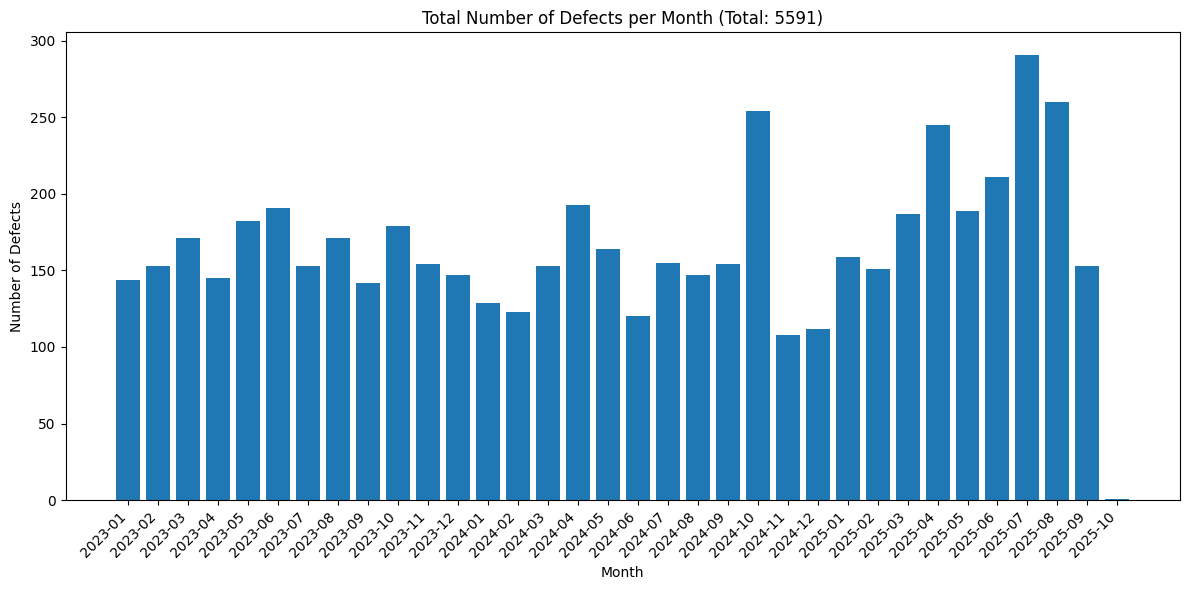

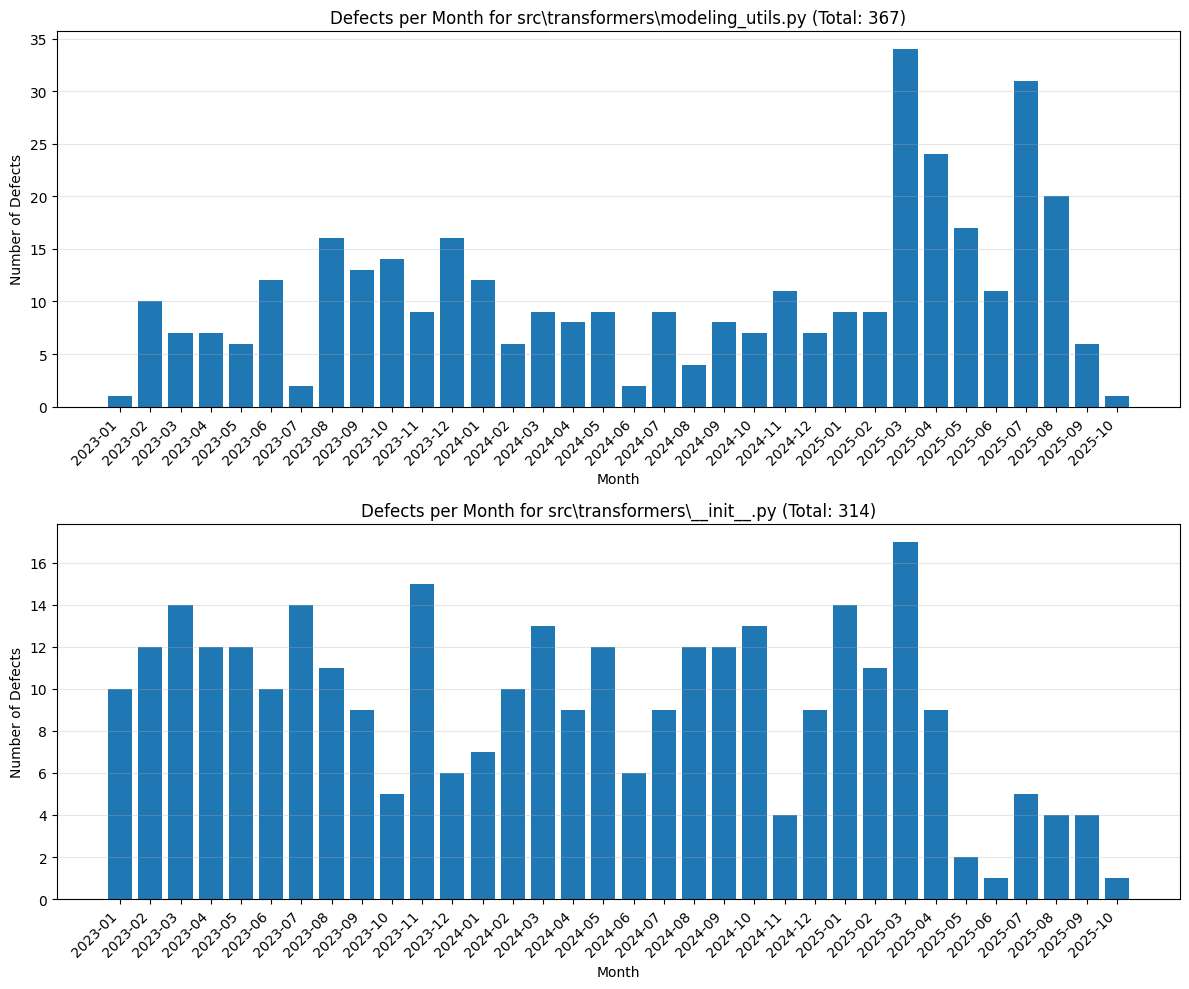

In [ ]:
import os
from pydriller import Repository
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt


repository = os.environ.get("REPOSITORY_PATH")
if repository is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

#tag = "v4.57.0"
date = datetime(2023, 1, 1)
keywords = ['bug', 'fix', 'error', 'issue', 'bugfix', 'hotfix', 'patch']

defects_per_month = defaultdict(int)  #{(year, month): count}
defects_per_file = defaultdict(int)   #{filename: count}
count = 0
total_defects = 0
for commit in Repository(repository, since=date).traverse_commits():
    count += 1
    message = commit.msg.lower()  #ignore casing
    isKeywordPresent = any(word in message for word in keywords)

    if isKeywordPresent:
        total_defects += 1
        year_month = (commit.committer_date.year, commit.committer_date.month)
        defects_per_month[year_month] += 1

        for file in commit.modified_files:
            defects_per_file[file.new_path] += 1

    if count % 500 == 0:
        print(f"Processed {count} commits so far")

print(f"Total commits processed: {count}")

#Task 1
months = sorted(defects_per_month.keys())
defect_counts = [defects_per_month[month] for month in months]
month_labels = [f"{year}-{month:02d}" for year, month in months]

plt.figure(figsize=(12, 6))
plt.bar(range(len(months)), defect_counts)
plt.xlabel('Month')
plt.ylabel('Number of Defects')
plt.title(f'Total Number of Defects per Month (Total: {total_defects})')
plt.xticks(range(len(months)), month_labels, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('TASK1_defects_per_month.png')


#Task 2
top_2_files = sorted(defects_per_file.items(), key=lambda x: x[1], reverse=True)[:2]
top_20_files = sorted(defects_per_file.items(), key=lambda x: x[1], reverse=True)[:20]
file1_path, file1_count = top_2_files[0]
file2_path, file2_count = top_2_files[1]
print(f"Top 2 files with most defects: {top_2_files}")
print(f"Top 2 files with most defects: {top_20_files}")

def get_file_defects_per_month(filepath):
    file_defects_per_month = defaultdict(int)
    
    for commit in Repository(repository, since=date, filepath=filepath).traverse_commits():
        message = commit.msg.lower() #ignore casing
        isKeywordPresent = any(word in message for word in keywords)
        
        if isKeywordPresent:
            year_month = (commit.committer_date.year, commit.committer_date.month)
            file_defects_per_month[year_month] += 1
        
    return file_defects_per_month

file1_defects_per_month = get_file_defects_per_month(file1_path)
file2_defects_per_month = get_file_defects_per_month(file2_path)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
#Plot for file 1
months_file1 = sorted(file1_defects_per_month.keys())
counts_file1 = [file1_defects_per_month[month] for month in months_file1]
labels_file1 = [f"{year}-{month:02d}" for year, month in months_file1]

ax1.bar(range(len(months_file1)), counts_file1)
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Defects')
ax1.set_title(f'Defects per Month for {file1_path} (Total: {file1_count})')
ax1.set_xticks(range(len(months_file1)))
ax1.set_xticklabels(labels_file1, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

#Plot for file 2
months_file2 = sorted(file2_defects_per_month.keys())
counts_file2 = [file2_defects_per_month[month] for month in months_file2]
labels_file2 = [f"{year}-{month:02d}" for year, month in months_file2]

ax2.bar(range(len(months_file2)), counts_file2)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Defects')
ax2.set_title(f'Defects per Month for {file2_path} (Total: {file2_count})')
ax2.set_xticks(range(len(months_file2)))
ax2.set_xticklabels(labels_file2, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('TASK1_top2_files_defects_per_month.png')

print("Finished processing.")

### Task 2

# Task 2 notes
# The metrics we select are cyclomatic comlexity (CC) and lines of code (LoC)

In [3]:
import os
from pathlib import Path
from radon.raw import analyze
from radon.complexity import cc_visit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Here we assume that the transormers repo was cloned into the parent folder
repository = os.environ.get("REPOSITORY_PATH")
if repository is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

repo = Path(repository)
repo.resolve()

WindowsPath('C:/Users/pio/Desktop/Local Code/FoSS/SoftwareEvolution/transformers')

In [4]:
# Funcitons 

def calculate_LoC_file(file_path: Path) -> int:
    file_text = file_path.read_text(encoding="utf-8")
    file_loc = analyze(file_text).loc
    return file_loc

def calculate_CC_file(file_path: Path) -> int:
    try:
        text = file_path.read_text(encoding="utf-8")
        blocks = cc_visit(text)
        return sum(b.complexity for b in blocks)
    except:
        print("error")
        return 0.0 # cant decypher file (There are only 2 errors in total)

def calculate_complexity_path(repo_path: Path) -> pd.DataFrame:
    file_data = []
    
    for path in repo_path.rglob("*.py"):
        path_length = len(path.parts)
        rel_path = path.relative_to(repo_path).parent

        file_data.append({
            "file_name": path.name,
            "parent_folder": rel_path,
            "parent_of_parent_folder": rel_path.parent,
            "LoC": calculate_LoC_file(path),
            "CC": calculate_CC_file(path)
        })


    return pd.DataFrame(file_data)

In [5]:
# Calculating CC and LoC Dataframe
df = calculate_complexity_path(repo_path=repo)

error
error


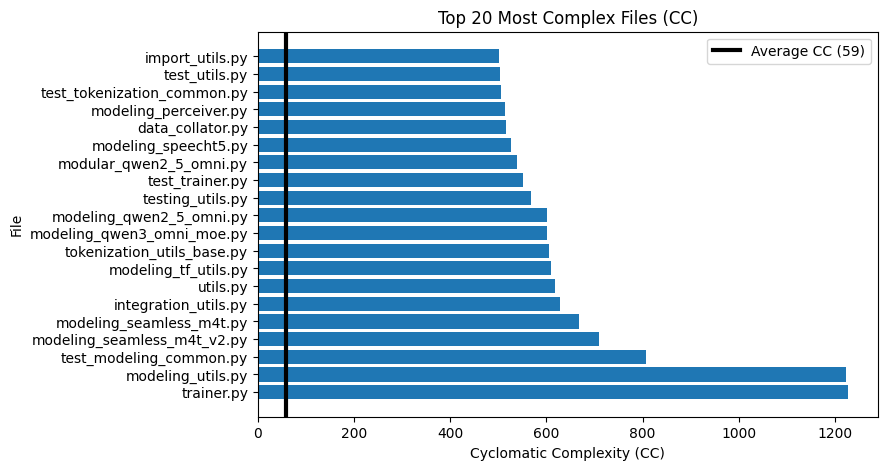

In [6]:
top20 = df.sort_values("CC", ascending=False).head(20)
average_cc = df["CC"].mean()

plt.figure(figsize=(8, 5))
plt.barh(top20["file_name"],top20["CC"],)
plt.axvline(average_cc,color="black",linewidth=3,label=f"Average CC ({average_cc:.0f})")

plt.xlabel("Cyclomatic Complexity (CC)")
plt.ylabel("File")
plt.title("Top 20 Most Complex Files (CC)")
plt.legend()
plt.show()

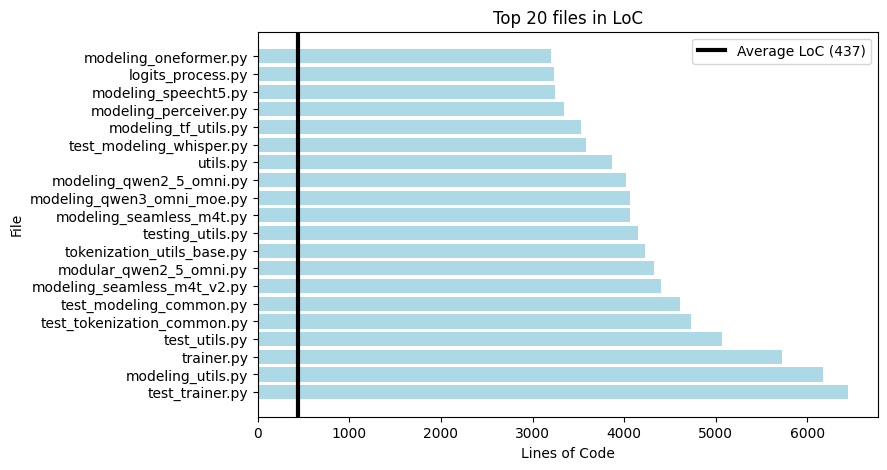

In [7]:
top20 = df.sort_values("LoC", ascending=False).head(20)
average_cc = df["LoC"].mean()

plt.figure(figsize=(8, 5))
plt.barh(top20["file_name"],top20["LoC"],color="lightblue",)
plt.axvline(average_cc,color="black",linewidth=3,label=f"Average LoC ({average_cc:.0f})")

plt.xlabel("Lines of Code")
plt.ylabel("File")
plt.title("Top 20 files in LoC")
plt.legend()
plt.show()

,parent_folder,count,LoC,CC
52,src\transformers\data,2,1114.000000,257.500000
360,src\transformers\models\qwen2_5_omni,5,1964.200000,251.600000
389,src\transformers\models\seamless_m4t_v2,3,1616.666667,237.333333
417,src\transformers\models\tapas,5,1571.800000,234.800000
368,src\transformers\models\qwen3_omni_moe,5,1697.600000,223.400000
57,src\transformers\generation,14,1315.071429,190.285714
50,src\transformers,63,1067.031746,167.095238
86,src\transformers\models\bigbird_pegasus,3,1157.666667,165.333333
235,src\transformers\models\groupvit,4,1001.750000,162.500000
277,src\transformers\models\longt5,4,1221.000000,161.000000


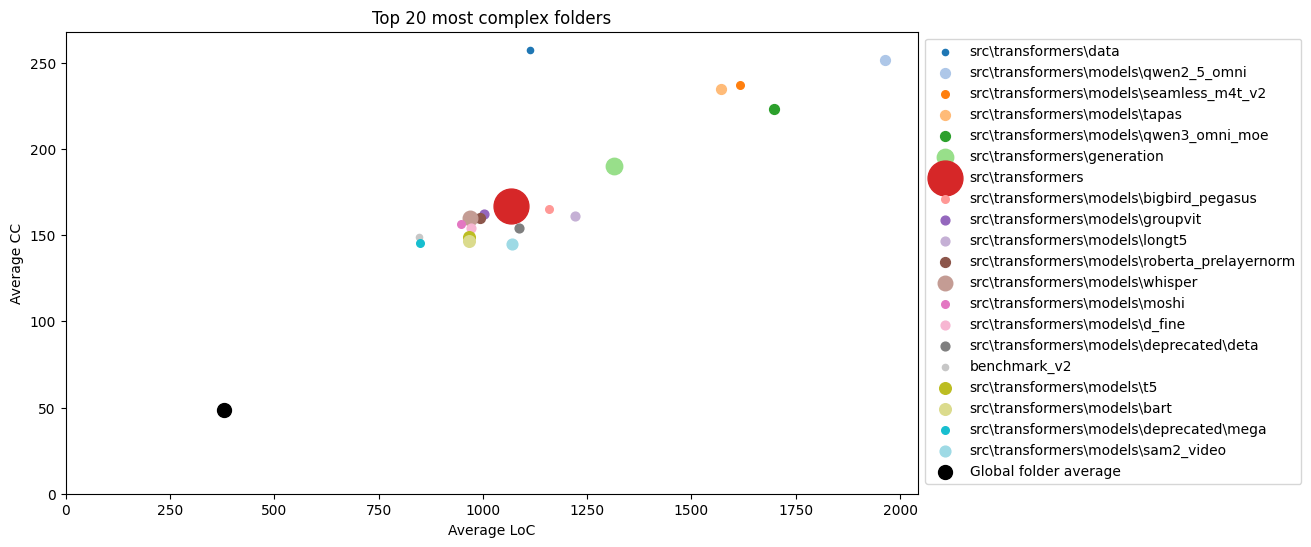

In [ ]:
df_folder_avg_data = df.groupby("parent_folder").agg(
    count=("parent_folder", "size"),
    LoC=("LoC", "mean"),
    CC=("CC","mean")
).reset_index()
top20_folders_CC = df_folder_avg_data.sort_values("CC", ascending=False).head(20)
display(top20_folders_CC.head(20))

# creating matching color to folder
categories = top20_folders_CC["parent_folder"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(categories)))
color_map = dict(zip(categories, colors))

plt.figure(figsize=(11, 6))

# plotting the 20 top folders
for _, row in top20_folders_CC.iterrows():
    current_folder = row["parent_folder"]
    plt.scatter(row["LoC"],row["CC"],color=color_map[current_folder],s=10*row["count"],label=current_folder)

plt.scatter(df_folder_avg_data["LoC"].mean(), df_folder_avg_data["CC"].mean(), color="black",s=100,label="Global folder average")

# making thie axis start at 0
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xlabel("Average LoC")
plt.ylabel("Average CC")
plt.title("Top 20 most complex folders")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()


# Task 3

## Calculating Logical Coupling and Visualization

This section computes the logical coupling between Python files in the repository based on their co-modification in commits since January 1, 2023. Non-Python files and `__init__.py` files are excluded from the analysis.

The top 10 most coupled file pairs are visualized using a network graph, where nodes represent files and edges indicate the strength of their coupling.

Analyzing repo...


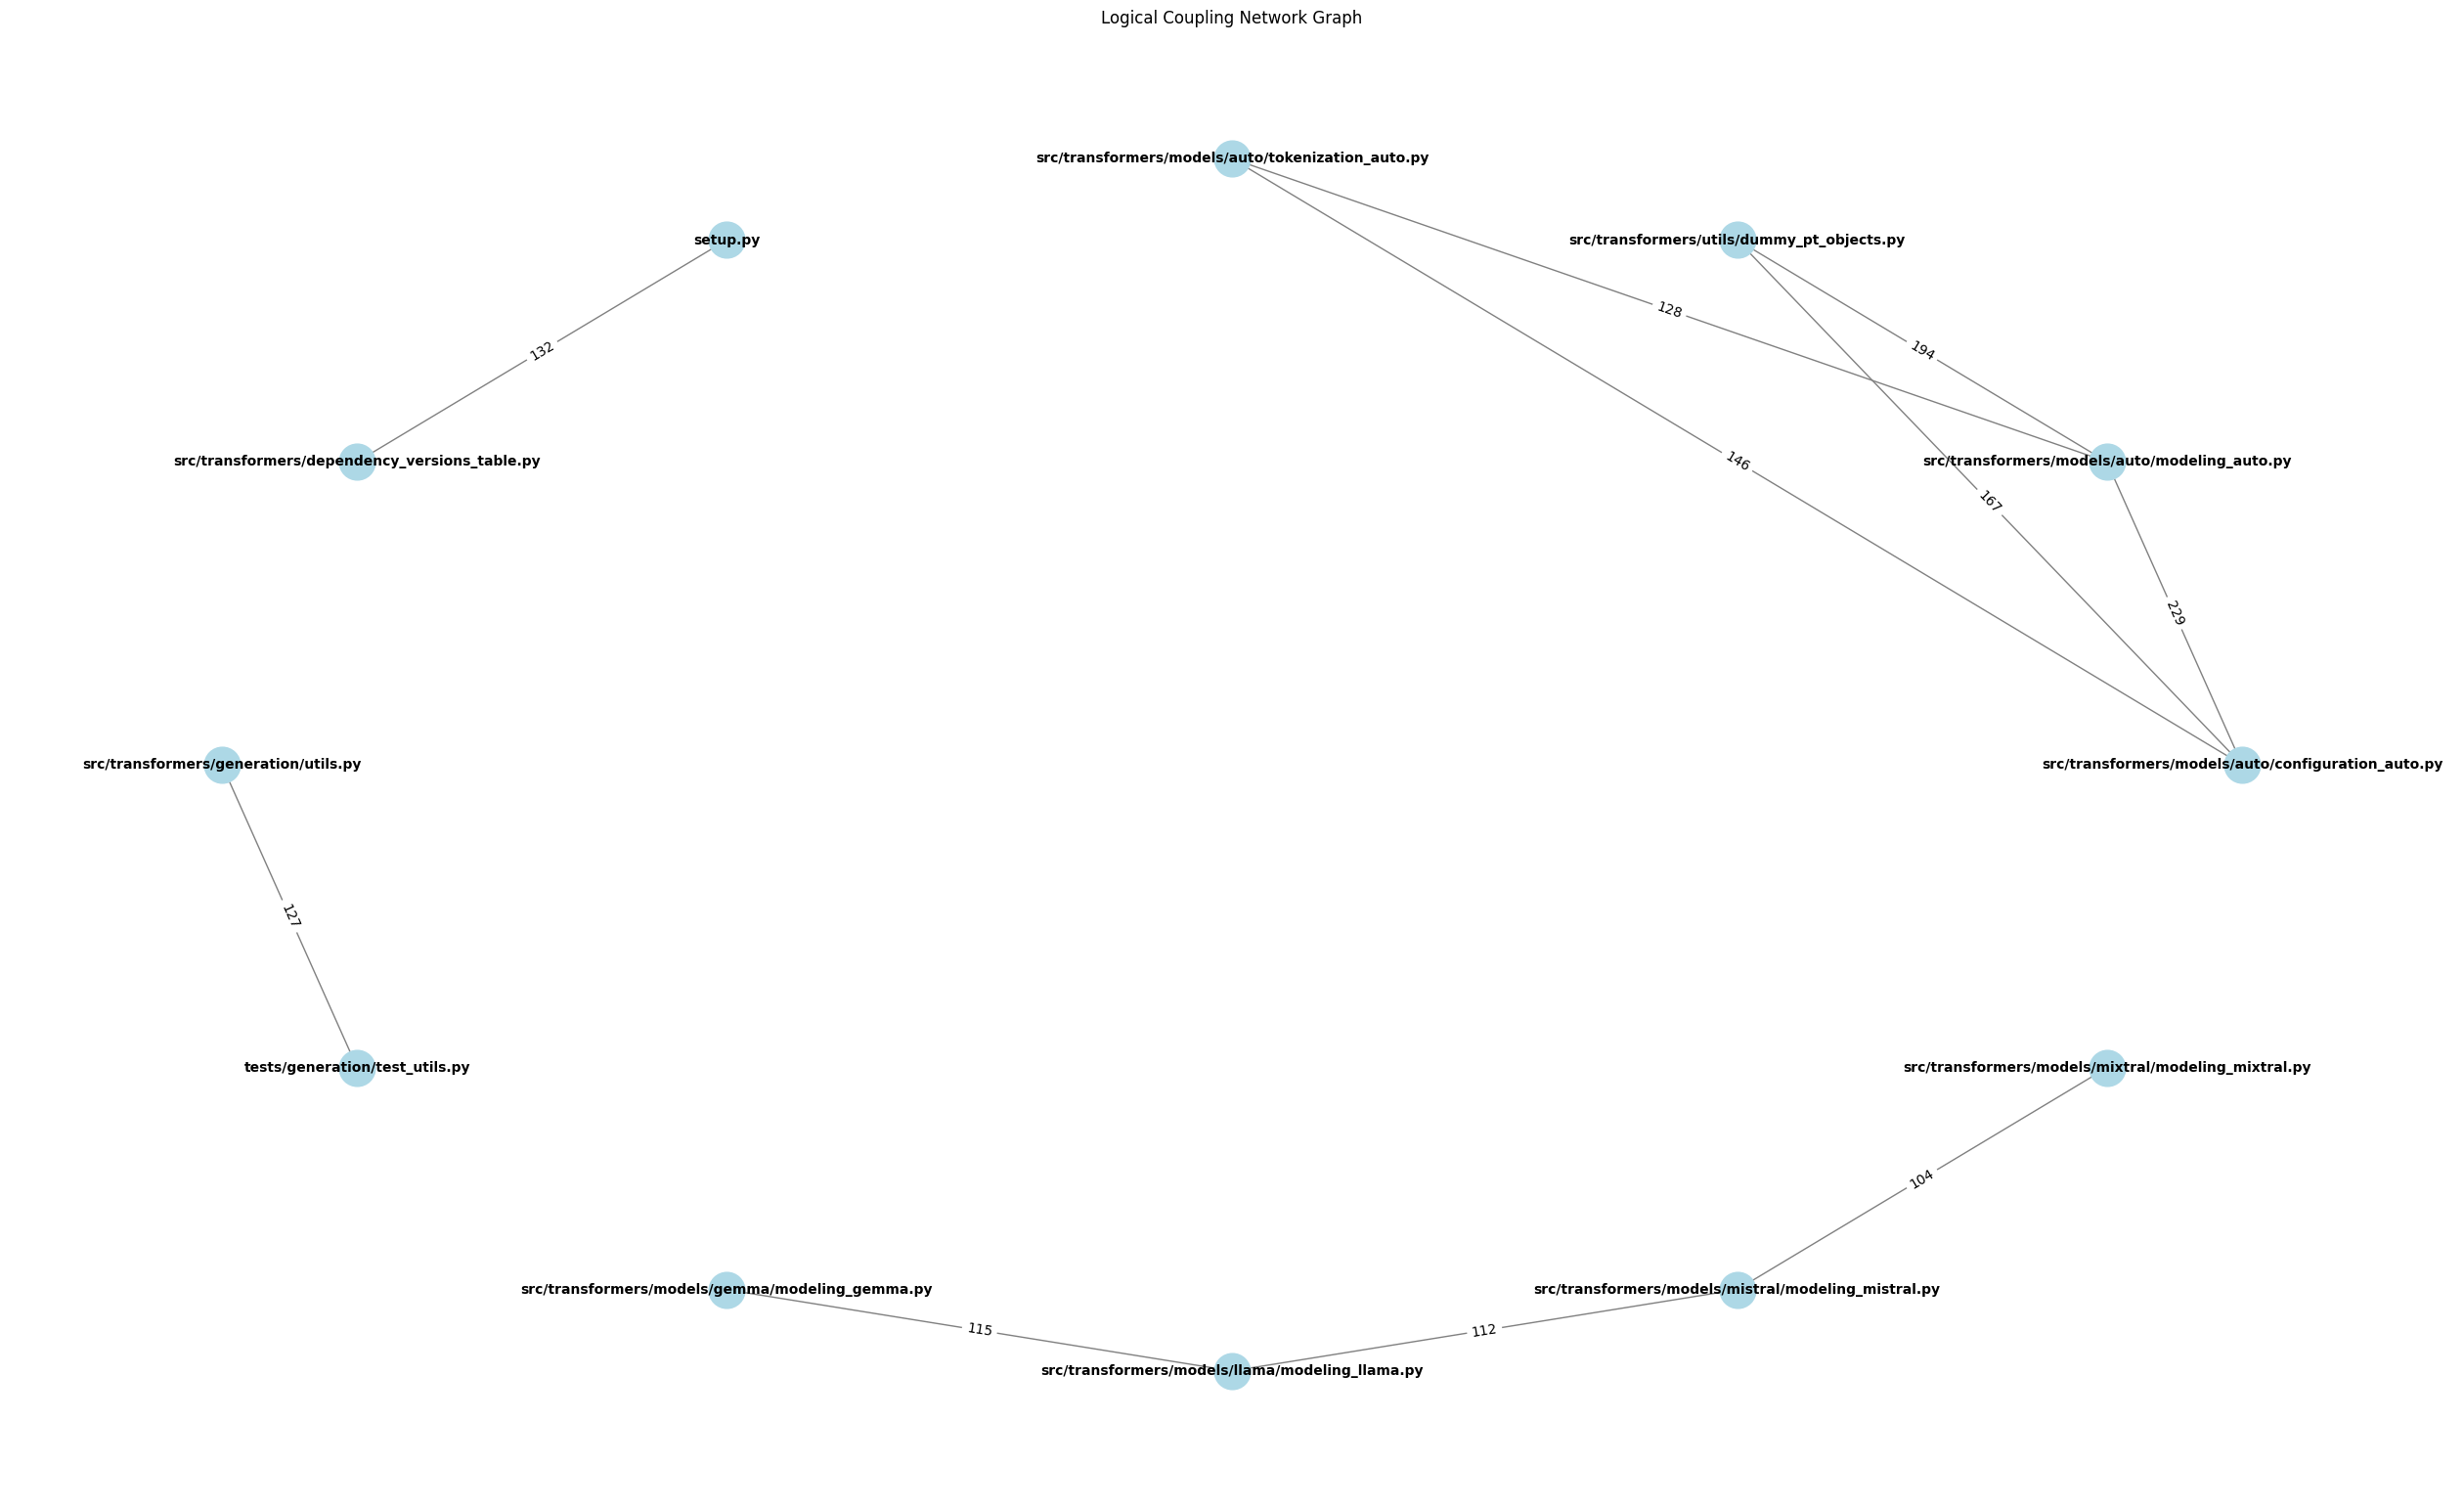

In [18]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os
from utils import plot_network_graph

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

DATE = datetime(2023, 1, 1)

def calculate_logical_coupling(repository, since_date):
    print("Analyzing repo...")
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = [
            file.new_path for file in commit.modified_files
            if file.new_path and file.new_path.endswith('.py') and
               os.path.basename(file.new_path) != "__init__.py"
        ]
        # Commit requires at least two modified files to form a pair
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        file_pair_coupling.update([tuple(sorted(pair)) for pair in file_pairs])

    return file_pair_coupling

calculated_coupling = calculate_logical_coupling(REPOSITORY, DATE) # This might take a while
top_10_pairs = calculated_coupling.most_common(10)
top_10_pairs = [(pair[0], pair[1], count) for pair, count in top_10_pairs]

plot_network_graph(top_10_pairs, "TASK3_logical_coupling.png", (25, 15))

## Analyzing Coupling Between Test and Non-Test Files

This section computes the logical coupling between test files (files starting with `test_`) and non-test Python files in the repository based on their co-modification in commits since January 1, 2023. Non-Python files and `__init__.py` files are excluded from the analysis.

The top 10 most coupled file pairs are visualized using a network graph, where nodes represent files and edges indicate the strength of their coupling.

Analyzing repo...


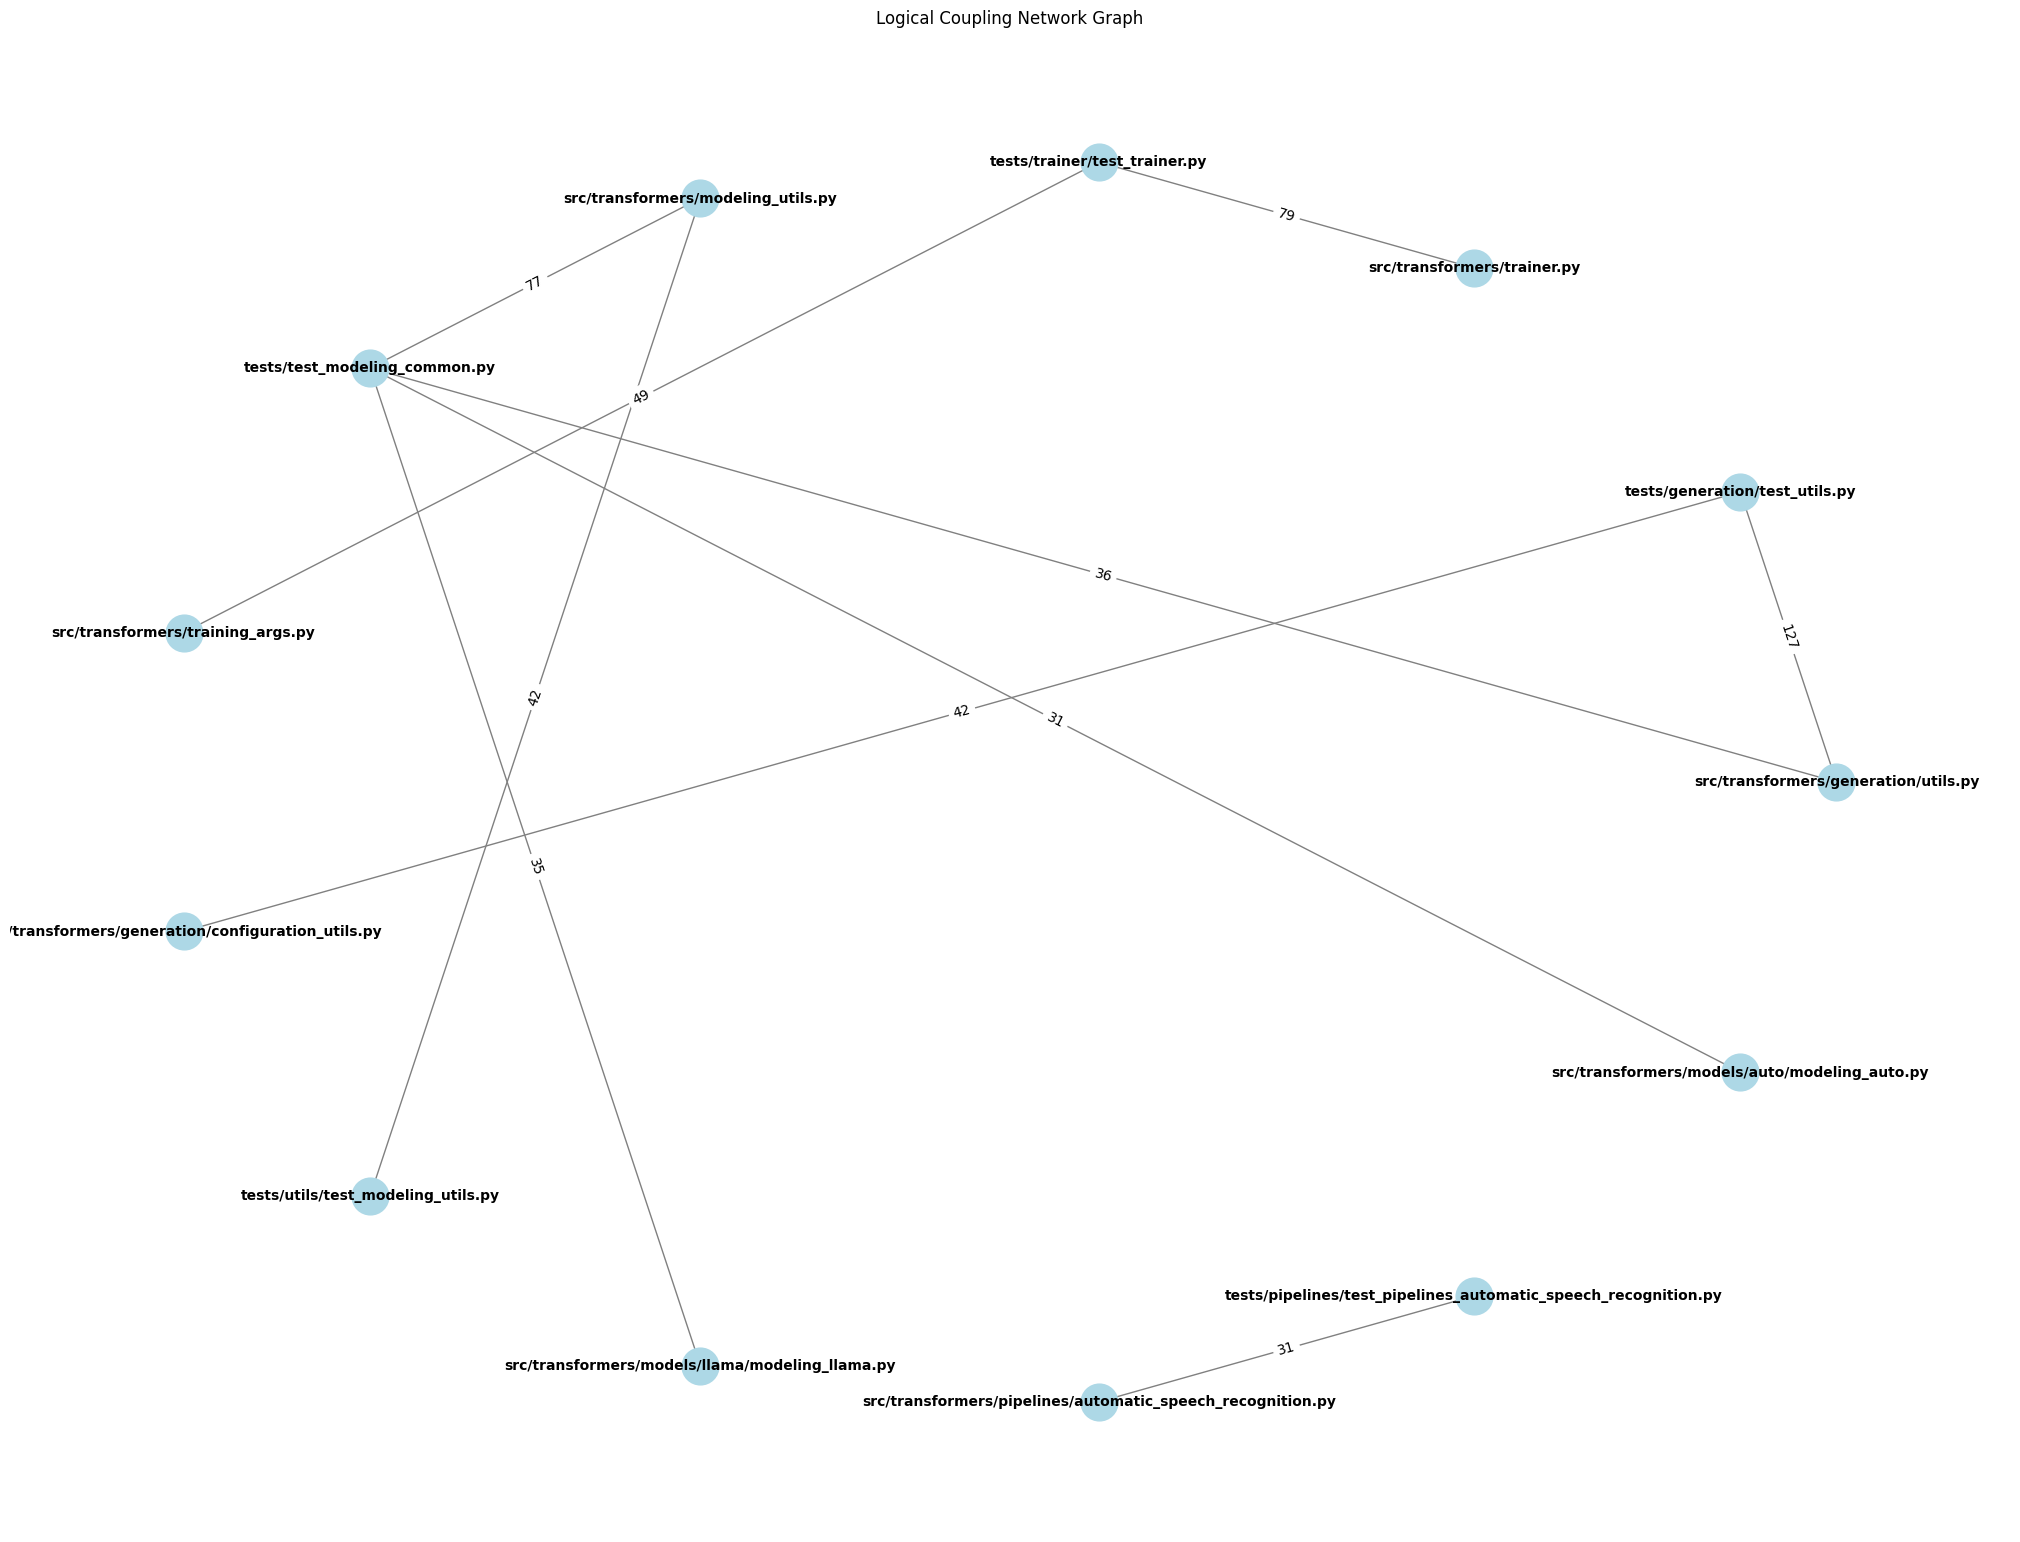

In [19]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os
from utils import plot_network_graph

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

DATE = datetime(2023, 1, 1)

def calculate_logical_coupling(repository, since_date):
    print("Analyzing repo...")
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = [
            file.new_path for file in commit.modified_files
            if file.new_path and file.new_path.endswith('.py') and
               os.path.basename(file.new_path) != "__init__.py"
        ]
        # Commit requires at least two modified files to form a pair
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        test_pairs = [
            pair for pair in file_pairs
            if (os.path.basename(pair[0]).startswith('test_') and not os.path.basename(pair[1]).startswith('test_')) or
               (os.path.basename(pair[1]).startswith('test_') and not os.path.basename(pair[0]).startswith('test_'))
        ]
        file_pair_coupling.update([tuple(sorted(pair)) for pair in test_pairs])

    return file_pair_coupling

calculated_coupling = calculate_logical_coupling(REPOSITORY, DATE) # This might take a while
top_10_pairs = calculated_coupling.most_common(10)
top_10_pairs = [(pair[0], pair[1], count) for pair, count in top_10_pairs]
plot_network_graph(top_10_pairs, "TASK3_test_logical_coupling.png", (20,15))

## Implementation for Finding Corresponding Test Files:

### Strategy 1: Matching based on project structure:

In [20]:
import os

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

def get_corresponding_test_file(repository, file_path):
    test_filename = f"test_{os.path.basename(file_path)}"
    relative_src_path = os.path.relpath(file_path, start=os.path.join("src", "transformers"))
    relative_src_path_dir = os.path.dirname(relative_src_path)
    test_file_path = os.path.join('tests', relative_src_path_dir, test_filename)

    if not os.path.exists(os.path.join(repository, test_file_path)):
        raise FileNotFoundError(f"Test file {test_file_path} does not exist.")
    return test_file_path

example_file = os.path.join("src" , "transformers", "generation", "utils.py")
print(f"For example file: {example_file}")
print(f"Corresponding test file: {get_corresponding_test_file(REPOSITORY, example_file)}")

For example file: src/transformers/generation/utils.py
Corresponding test file: tests/generation/test_utils.py


### Strategy 2: Matching based on logical coupling:

In [21]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os

REPOSITORY = os.environ.get("REPOSITORY_PATH")
if REPOSITORY is None:
    raise ValueError("Please source the setup.sh script or set the REPOSITORY_PATH environment variable to the local path of the cloned repository.")

DATE = datetime(2023, 1, 1)

def get_corresponding_test_file(repository, since_date, file_path):
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = {
            file.new_path for file in commit.modified_files
            if file.new_path and file.new_path.endswith('.py') and
               os.path.basename(file.new_path) != "__init__.py"
        }

        # Skipt irrelevant commits
        if file_path not in modified_files:
            continue
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        test_pairs = [
            pair for pair in file_pairs
            if (os.path.basename(pair[0]).startswith('test_') and pair[1] == file_path) or
               (os.path.basename(pair[1]).startswith('test_') and pair[0] == file_path)
        ]
        file_pair_coupling.update([tuple(sorted(pair)) for pair in test_pairs])

    most_common = file_pair_coupling.most_common(1)
    if not most_common:
        raise ValueError(f"No coupled test file found for {file_path}.")
    pair = most_common[0][0]
    if os.path.basename(pair[1]).startswith('test_'):
        return pair[1]
    return pair[0]

example_file = os.path.join("src" , "transformers", "generation", "utils.py")
print(f"For example file: {example_file}")
print(f"Corresponding test file: {get_corresponding_test_file(REPOSITORY, DATE, example_file)}")

For example file: src/transformers/generation/utils.py
Corresponding test file: tests/generation/test_utils.py
